In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras import regularizers
from sklearn.metrics import f1_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')
curr = os.getcwd()
project_root = os.path.abspath(os.path.join(curr, '..', '..'))

if project_root not in sys.path:
    sys.path.append(project_root)
from ai.features import FEATURES
from ai.help_folder.backtest import backtest, production_backtest, filter_signals
from ai.help_folder.help import prepare_data, stage1, stage2, calculate_base_features, optimize_threshold, generate_final_report, download, save_models, save_artifacts_json, print_stage_report

In [ ]:
# Параметры
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TICKER = "AAPL"
START_DATE = "2010-01-01"
END_DATE = "2023-12-31"
INTERVAL = "1d"

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEQUENCE_LENGTH = 15

LSTM_UNITS = 16
DENSE_UNITS = 8
DROPOUT_RATE = 0.5
LEARNING_RATE = 0.0001
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE_ES = 2
PATIENCE_LR = 5

MOVE_THRESHOLD = 0.01
HORIZON = 3

COMMISSION = 0.001
SLIPPAGE = 0.0005
MAX_POSITION_SIZE = 0.1
MAX_DRAWDOWN = 0.15     

L2_REG = 0.1
TOP_K_PERCENT = 5
SHORT_BASE_TH = 30
LONG_BASE_TH = 70


MODEL_PATH = '../models/model_lstm'

In [3]:
from tensorflow.keras import layers, regularizers, Sequential
import tensorflow as tf

def create_model(input_dim, name="model_lstm"):
    reg = regularizers.l2(L2_REG) 

    model = tf.keras.Sequential([
        layers.Input(shape=input_dim),
        layers.GaussianNoise(0.05), 
        layers.LSTM(LSTM_UNITS, 
                    return_sequences=False,
                    kernel_regularizer=reg,
                    recurrent_regularizer=reg,
                    bias_regularizer=reg,
                    recurrent_dropout=0.2), 
        
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE), 
        
        # Полносвязный слой: используем твой DENSE_UNITS (8)
        layers.Dense(DENSE_UNITS, 
                     activation='relu',
                     kernel_regularizer=reg),
        
        layers.Dropout(0.3), # Дополнительный слой защиты
        
        layers.Dense(1, activation='sigmoid')
    ], name=name)

    # Компиляция с твоим LEARNING_RATE (0.0001)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
        # Label Smoothing защищает от "зубрежки" Apple
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

In [4]:
# ЗАГРУЗКА ДАННЫХ
raw_data, raw_df = download(TICKER, START_DATE, END_DATE, interval=INTERVAL)
print(f"📊 Загружено {len(raw_df)} записей")

spy = yf.download("SPY", start=START_DATE, end=END_DATE, progress=False)
vix = yf.download("^VIX", start=START_DATE, end=END_DATE, progress=False)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

# ПОДГОТОВКА ДАННЫХ
print("\n🔧 Подготовка данных...")
df = calculate_base_features(raw_df, spy, vix)
df = df.dropna().reset_index(drop=True)

res_prepare_data = prepare_data(
    df, TRAIN_SPLIT, VAL_SPLIT, SEQUENCE_LENGTH,
    move_threshold=MOVE_THRESHOLD, horizon=HORIZON, FEATURES1=FEATURES
)

📊 Загружено 3522 записей

🔧 Подготовка данных...
✅ Создано 34 признаков. Всего строк: 3522
✅ Train: 2448 | Val: 513 | Test: 513


In [5]:
# STAGE 1: MOVE and HOLD
res_stage1 = stage1(
    res_prepare_data['X_train'], 
    res_prepare_data['X_val'], 
    res_prepare_data['X_test'],
    res_prepare_data['y1_train'], 
    res_prepare_data['y1_val'], 
    res_prepare_data['y1_test'],
    res_prepare_data['cw1'],
    create_model=create_model, # Теперь это передается корректно
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES,
    PATIENCE_LR=PATIENCE_LR
)


 STAGE 1: MOVE vs HOLD (Volatility/Activity Filter)
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5645 - auc: 0.5021 - loss: 8.5948 - val_accuracy: 0.5926 - val_auc: 0.5336 - val_loss: 8.3330 - learning_rate: 1.0000e-04
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5609 - auc: 0.4963 - loss: 8.4669 - val_accuracy: 0.5887 - val_auc: 0.5360 - val_loss: 8.2043 - learning_rate: 1.0000e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5756 - auc: 0.5062 - loss: 8.3292 - val_accuracy: 0.5887 - val_auc: 0.5336 - val_loss: 8.0777 - learning_rate: 1.0000e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5588 - auc: 0.4899 - loss: 8.2047 - val_accuracy: 0.5906 - val_auc: 0.5345 - val_loss: 7.9538 - learning_rate: 1.0000e-04
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5474 - auc: 0.4746 - loss: 8.0916 - val_accuracy: 0.5926 - val_auc: 0.5350 - val_loss: 7.8320 - learning_rate: 1.0000e-04
Epoch 6/30
20/20

In [ ]:
# STAGE 2: UP and DOWN
res_stage2 = stage2(
    X_train=res_prepare_data['X_train'],
    X_val=res_prepare_data['X_val'],
    X_test=res_prepare_data['X_test'],
    y2_train=res_prepare_data['y2_train'],
    y2_val=res_prepare_data['y2_val'],
    y2_test=res_prepare_data['y2_test'],
    mask1_train=res_stage1['mask_train'],
    mask1_val=res_stage1['mask_val'],
    mask1_test=res_stage1['mask_test'],
    create_model=create_model, 
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES
)


 STAGE 2: UP vs DOWN (Directional Model)
Обучение на 2074 сбалансированных примерах (50/50)
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4913 - auc: 0.4888 - loss: 8.9190 - val_accuracy: 0.4522 - val_auc: 0.4794 - val_loss: 8.5815
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4971 - auc: 0.4907 - loss: 8.8038 - val_accuracy: 0.4498 - val_auc: 0.4805 - val_loss: 8.4826
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5116 - auc: 0.5072 - loss: 8.6761 - val_accuracy: 0.4474 - val_auc: 0.4797 - val_loss: 8.3874
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5010 - auc: 0.5055 - loss: 8.5572 - val_accuracy: 0.4426 - val_auc: 0.4795 - val_loss: 8.2935
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5043 - auc: 0.5000 - loss: 8.4704 - val_accuracy: 0.4402 - val_auc: 0.4799 - val_loss: 8.2031
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5063 - auc: 0.5008 - loss: 8.3570 - val_accuracy: 0.

In [7]:
print_stage_report(
    res_prepare_data['y1_test'],
    res_stage1['mask_test'].astype(int), 
    "Stage 1 (MOVE vs HOLD)",
    ['HOLD', 'MOVE']
)

temp_preds_s2 = (res_stage2['probs_full'] >= 0.5).astype(int)
print_stage_report(
    res_prepare_data['y2_test'],
    temp_preds_s2,
    "Stage 2 (UP vs DOWN) - Raw Performance",
    ['DOWN', 'UP']
)


Stage 1 (MOVE vs HOLD):
              precision    recall  f1-score   support

        HOLD       0.78      0.33      0.47       375
        MOVE       0.29      0.74      0.42       138

    accuracy                           0.44       513
   macro avg       0.53      0.54      0.44       513
weighted avg       0.65      0.44      0.45       513


Stage 2 (UP vs DOWN) - Raw Performance:
              precision    recall  f1-score   support

        DOWN       0.49      0.67      0.56       243
          UP       0.55      0.37      0.45       270

    accuracy                           0.51       513
   macro avg       0.52      0.52      0.51       513
weighted avg       0.52      0.51      0.50       513



In [ ]:
# Создаем финальные сигналы для GRU
from ai.help_folder.backtest import get_statistical_signals
y_pred_final = get_statistical_signals(
    res_stage1['probs_test'], 
    res_stage2['probs_full'], 
    top_k_percent=TOP_K_PERCENT,
    short_base_th=SHORT_BASE_TH,
    long_base_th=LONG_BASE_TH
)

# Проверь количество сигналов в обе стороны
print(f"LSTM BUY signals: {np.sum(y_pred_final == 1)}")
print(f"LSTM SELL signals: {np.sum(y_pred_final == -1)}")

LSTM BUY signals: 8
LSTM SELL signals: 8


ROC AUC Stage 1: 0.5415
ROC AUC Stage 2: 0.4857


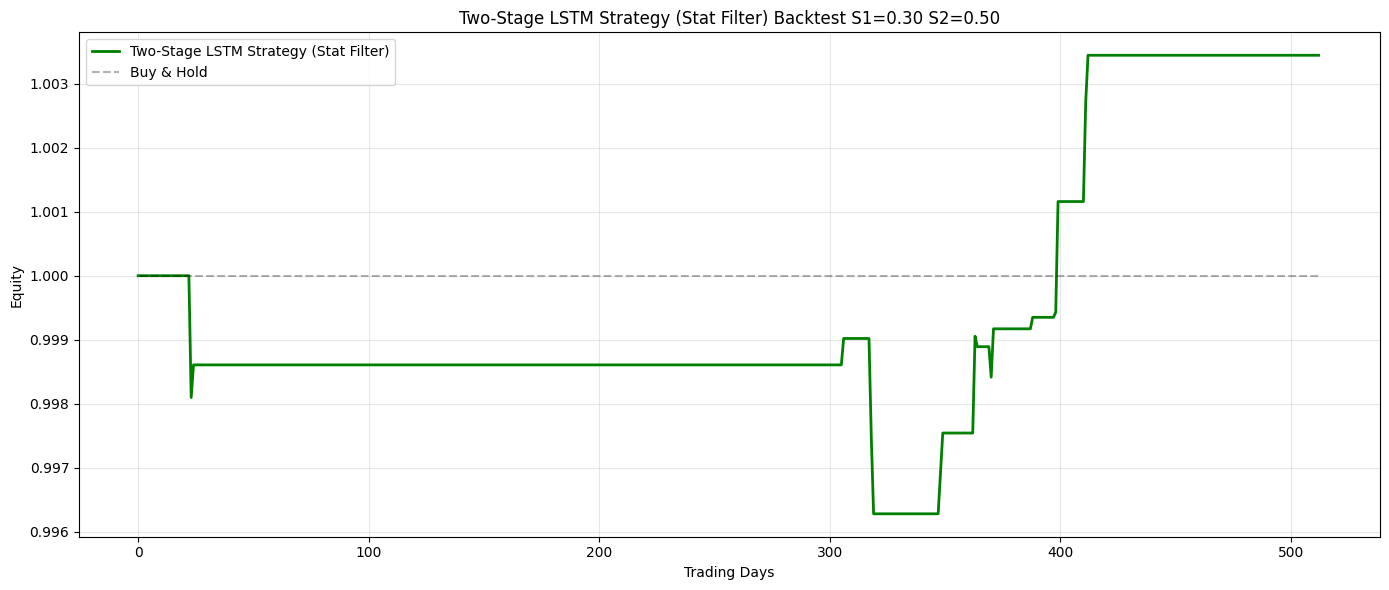

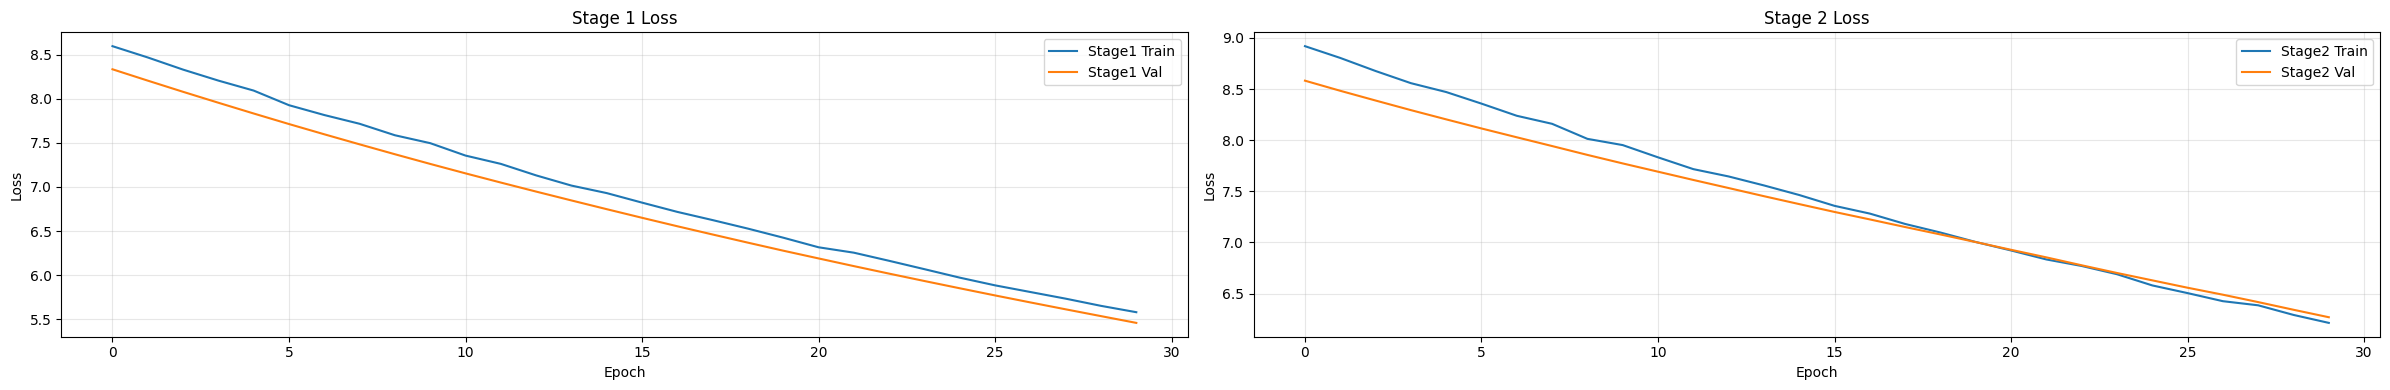

In [9]:
from sklearn.metrics import roc_auc_score

auc_s1 = roc_auc_score(res_prepare_data['y1_test'], res_stage1['probs_test'])
print(f"ROC AUC Stage 1: {auc_s1:.4f}")

mask = res_stage1['mask_test']
y2_true_filtered = res_prepare_data['y2_test'][mask]
valid_idx = ~np.isnan(y2_true_filtered)

if len(y2_true_filtered[valid_idx]) > 0:
    auc_s2 = roc_auc_score(y2_true_filtered[valid_idx], res_stage2['probs_filtered'][valid_idx])
    print(f"ROC AUC Stage 2: {auc_s2:.4f}")
else:
    print("Stage 2 AUC: недостаточно данных для расчета")

results = production_backtest(
    df_test=res_prepare_data['df_test'],
    signals=y_pred_final, 
    commission=COMMISSION,
    slippage=SLIPPAGE,
    max_position_size=MAX_POSITION_SIZE,
    horizon=HORIZON
)

history_stages = [res_stage1['history'], res_stage2['history']]
thresholds = {"S1": res_stage1['threshold'], "S2": 0.5}

backtest(
    results=results,
    history_stages=history_stages,
    strategy_name="Two-Stage LSTM Strategy (Stat Filter)",
    thresholds=thresholds,
    save_dir="../models/model_lstm"
)


In [10]:
s1_f1 = res_stage1.get('f1_val', 0.0) 
s2_threshold = 0.5 
s2_f1 = 0.0 

params = {
    'threshold_stage1': res_stage1['threshold'],
    'threshold_stage2': s2_threshold,
    'move_threshold': MOVE_THRESHOLD,
    'horizon': HORIZON,
    'commission': COMMISSION,
    'slippage': SLIPPAGE,
    'max_position_size': MAX_POSITION_SIZE,
    'max_drawdown': MAX_DRAWDOWN,
    'sequence_length': SEQUENCE_LENGTH
}

backtest_results = {
    "total_return": results.get('total_return', 0),
    "sharpe_ratio": results.get('sharpe', results.get('sharpe_ratio', 0)),
    "max_drawdown": results.get('max_drawdown', 0),
    "win_rate": results.get('win_rate', 0),
    "trades": results.get('trades', 0),
    "avg_pnl": results.get('avg_pnl', 0)
}

save_artifacts_json(
    base_dir=MODEL_PATH,
    strategy_name="two_stage",
    res_stage1=res_stage1,
    res_stage2=res_stage2,
    FEATURES=FEATURES,
    params=params,
    backtest_results=backtest_results
)

save_models(
    model_stage1=res_stage1['model'],
    model_stage2=res_stage2['model'],
    scaler=res_prepare_data['scaler'],
    params=params,
    base_dir=MODEL_PATH,
    features=FEATURES
)

generate_final_report(
    results=results,
    model_type="two_stage",
    stage1_metrics={
        "threshold": res_stage1['threshold'],
        "f1": s1_f1
    },
    stage2_metrics={
        "threshold": s2_threshold,
        "f1": s2_f1
    },
    ml_metrics={
        "Stage 1 F1": s1_f1,
        "Stage 2 F1": s2_f1
    }
)

✅ JSON summary saved: ../models/model_lstm/two_stage/artifacts_summary.json
✅ Model Stage 1 saved: ../models/model_lstm/strategy/model_stage1.h5
✅ Model Stage 2 saved: ../models/model_lstm/strategy/model_stage2.h5
✅ Scaler, features, and params (WITH features list) saved to ../models/model_lstm/strategy

📁 Все артефакты сохранены в ../models/model_lstm/strategy

📋 ИТОГОВЫЙ ОТЧЁТ

🎯 Two-Stage Classification:
   Stage 1: MOVE vs HOLD (Threshold=0.3, F1=0.5483)
   Stage 2: UP vs DOWN (Threshold=0.5, F1=0.0000)

Метрики:
   Stage 1 F1: 0.5483
   Stage 2 F1: 0.0000

💰 Production Backtest:
   Total Return: 0.3%
   Sharpe Ratio: 0.57
   Max Drawdown: 0.4%
Trades: 9
   Win Rate: 77.8%
